# 19 - Statistical Analysis on Independent Dataset (Normalised Images)

Repeat the NB 14a analysis on the independent dataset (1 study per patient, 55 studies).

This eliminates repeated-measures bias: every observation is from a different patient.

**Methods (same as NB 14a):**
- Normality check (Shapiro-Wilk) to choose t-test vs Mann-Whitney U
- Effect sizes: Cohen's d (normal) or rank-biserial correlation (non-normal)
- Benjamini-Hochberg FDR correction
- Correlation matrix and highly correlated pair count

**Key difference from NB 14a:** No motivo-stratified analysis. The independent dataset has very uneven motivo distribution (23 motivo-1, 0 motivo-3, 1 motivo-5) because the selection rule picks early studies, so stratification is not meaningful here.

In [1]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Imports OK")

Imports OK


In [2]:
df = pd.read_csv(os.path.join("reports", "18_independent_dataset_normalised.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]

rejection = df[df["rejection"] == 1]
no_rejection = df[df["rejection"] == 0]

print(f"Independent dataset: {len(df)} studies, {df['patient_id'].nunique()} patients")
print(f"No rejection: {len(no_rejection)}")
print(f"Rejection: {len(rejection)}")
print(f"Radiomics features: {len(feature_cols)}")

Independent dataset: 55 studies, 55 patients
No rejection: 34
Rejection: 21
Radiomics features: 93


## Normality check

In [3]:
normality_results = []

for feat in feature_cols:
    vals_no_rej = no_rejection[feat].dropna()
    vals_rej = rejection[feat].dropna()

    _, p_no_rej = stats.shapiro(vals_no_rej)
    _, p_rej = stats.shapiro(vals_rej)

    both_normal = (p_no_rej > 0.05) and (p_rej > 0.05)
    normality_results.append({
        "feature": feat,
        "shapiro_p_no_rej": p_no_rej,
        "shapiro_p_rej": p_rej,
        "both_normal": both_normal,
    })

norm_df = pd.DataFrame(normality_results)
n_normal = norm_df["both_normal"].sum()
print(f"Features passing normality in both groups: {n_normal}")
print(f"Features failing normality (will use Mann-Whitney): {len(norm_df) - n_normal}")

Features passing normality in both groups: 45
Features failing normality (will use Mann-Whitney): 48


## Univariate testing (uncorrected)

In [4]:
test_results = []

for i, feat in enumerate(feature_cols):
    vals_no_rej = no_rejection[feat].dropna().values
    vals_rej = rejection[feat].dropna().values

    is_normal = norm_df.loc[i, "both_normal"]

    if is_normal:
        stat, p_value = stats.ttest_ind(vals_no_rej, vals_rej, equal_var=False)
        test_name = "t-test"
        pooled_std = np.sqrt(
            ((len(vals_no_rej) - 1) * vals_no_rej.std(ddof=1)**2 +
             (len(vals_rej) - 1) * vals_rej.std(ddof=1)**2) /
            (len(vals_no_rej) + len(vals_rej) - 2)
        )
        if pooled_std > 0:
            effect_size = (vals_rej.mean() - vals_no_rej.mean()) / pooled_std
        else:
            effect_size = 0.0
    else:
        stat, p_value = stats.mannwhitneyu(vals_no_rej, vals_rej, alternative="two-sided")
        test_name = "Mann-Whitney"
        n1 = len(vals_no_rej)
        n2 = len(vals_rej)
        effect_size = 1 - (2 * stat) / (n1 * n2)

    test_results.append({
        "feature": feat,
        "test": test_name,
        "statistic": stat,
        "p_value": p_value,
        "effect_size": effect_size,
        "mean_no_rej": vals_no_rej.mean(),
        "mean_rej": vals_rej.mean(),
        "median_no_rej": np.median(vals_no_rej),
        "median_rej": np.median(vals_rej),
    })

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values("p_value").reset_index(drop=True)

print(f"Tests used: {results_df['test'].value_counts().to_dict()}")

Tests used: {'Mann-Whitney': 48, 't-test': 45}


In [5]:
significant = results_df[results_df["p_value"] < 0.05]
print(f"Features with uncorrected p < 0.05: {len(significant)} out of {len(results_df)}")
print()

if len(significant) > 0:
    display_cols = ["feature", "test", "p_value", "effect_size", "median_no_rej", "median_rej"]
    print(significant[display_cols].to_string(index=False))

print("\nTop 10 features by p-value:")
display_cols = ["feature", "test", "p_value", "effect_size"]
print(results_df[display_cols].head(10).to_string(index=False))

Features with uncorrected p < 0.05: 24 out of 93

                                        feature         test  p_value  effect_size  median_no_rej  median_rej
               original_firstorder_90Percentile Mann-Whitney 0.004142    -0.464986     129.165392  101.622338
            original_firstorder_RootMeanSquared Mann-Whitney 0.004619    -0.459384      84.281854   60.826287
                       original_firstorder_Mean Mann-Whitney 0.005428    -0.450980      73.764081   44.666926
                     original_firstorder_Median Mann-Whitney 0.006704    -0.439776      72.512483   41.245811
               original_firstorder_10Percentile Mann-Whitney 0.011714    -0.408964      23.695170  -11.805803
                    original_firstorder_Minimum Mann-Whitney 0.014232    -0.397759     -37.987842  -70.354177
                    original_firstorder_Maximum Mann-Whitney 0.014429    -0.396359     253.518473  195.873948
                         original_glcm_Contrast Mann-Whitney 0.027188 

## FDR correction (Benjamini-Hochberg)

In [6]:
reject_fdr, pvals_corrected, _, _ = multipletests(
    results_df["p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

results_df["p_value_fdr"] = pvals_corrected
results_df["significant_fdr"] = reject_fdr

n_fdr = results_df["significant_fdr"].sum()
print(f"Features surviving FDR correction: {n_fdr}")

if n_fdr > 0:
    sig_fdr = results_df[results_df["significant_fdr"]]
    print(sig_fdr[["feature", "p_value", "p_value_fdr", "effect_size"]].to_string(index=False))

Features surviving FDR correction: 0


## Compare with full dataset results (NB 14a)

In [7]:
full_stats = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features_normalised.csv"))

# Merge on feature name to compare p-values
comparison = pd.merge(
    results_df[["feature", "p_value", "effect_size"]],
    full_stats[["feature", "p_value", "effect_size"]],
    on="feature",
    suffixes=("_independent", "_full")
)

# Count how many features are p < 0.05 in each
n_sig_ind = (comparison["p_value_independent"] < 0.05).sum()
n_sig_full = (comparison["p_value_full"] < 0.05).sum()
print(f"Features with p < 0.05 (uncorrected):")
print(f"  Full dataset (137 studies): {n_sig_full}")
print(f"  Independent (55 studies):   {n_sig_ind}")
print()

# Show top 10 from independent with their full-dataset p-values
comparison_sorted = comparison.sort_values("p_value_independent")
print("Top 10 features (independent), with full-dataset comparison:")
print(comparison_sorted.head(10).to_string(index=False))

Features with p < 0.05 (uncorrected):
  Full dataset (137 studies): 4
  Independent (55 studies):   24

Top 10 features (independent), with full-dataset comparison:
                                        feature  p_value_independent  effect_size_independent  p_value_full  effect_size_full
               original_firstorder_90Percentile             0.004142                -0.464986      0.112744         -0.174254
            original_firstorder_RootMeanSquared             0.004619                -0.459384      0.075606         -0.195186
                       original_firstorder_Mean             0.005428                -0.450980      0.048571         -0.216641
                     original_firstorder_Median             0.006704                -0.439776      0.041438         -0.223967
               original_firstorder_10Percentile             0.011714                -0.408964      0.039571         -0.226060
                    original_firstorder_Minimum             0.014232           

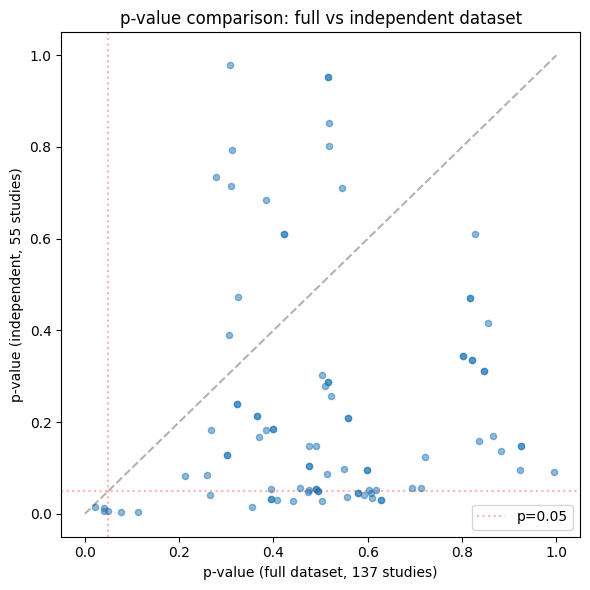

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(comparison["p_value_full"], comparison["p_value_independent"],
           alpha=0.5, s=20)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.axhline(0.05, color="r", linestyle=":", alpha=0.3, label="p=0.05")
ax.axvline(0.05, color="r", linestyle=":", alpha=0.3)
ax.set_xlabel("p-value (full dataset, 137 studies)")
ax.set_ylabel("p-value (independent, 55 studies)")
ax.set_title("p-value comparison: full vs independent dataset")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("reports", "19_pvalue_comparison_full_vs_independent_normalised.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Box plots of features with uncorrected p < 0.05

The 4 features that reached p < 0.05 before FDR correction. None survived multiple testing correction.

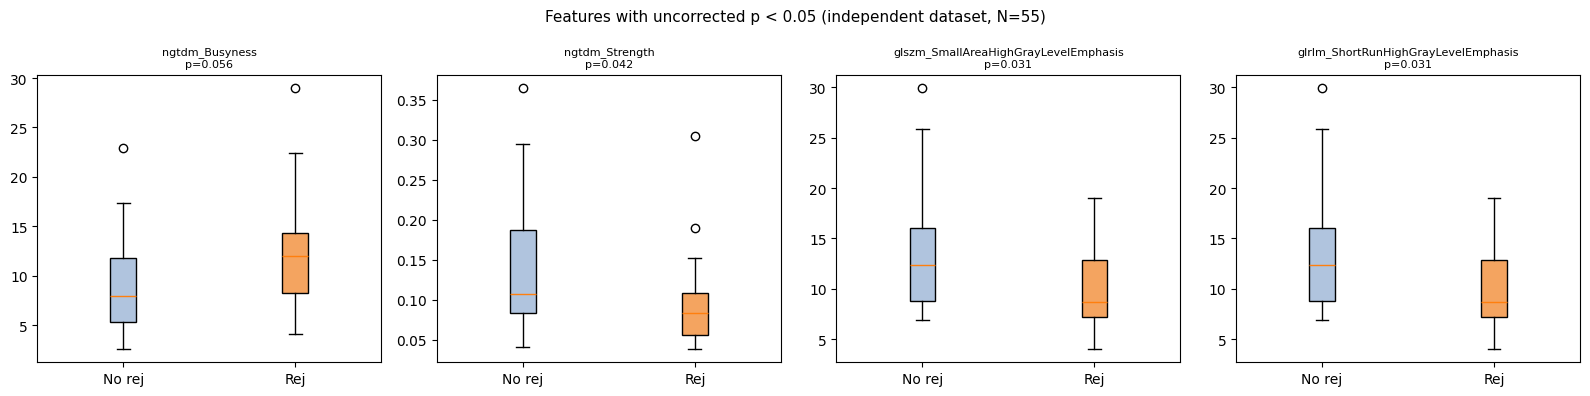

Saved to reports/19_boxplots_top_features_normalised.png


In [9]:
top4_features = [
    "original_ngtdm_Busyness",
    "original_ngtdm_Strength",
    "original_glszm_SmallAreaHighGrayLevelEmphasis",
    "original_glrlm_ShortRunHighGrayLevelEmphasis",
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(top4_features):
    data_no = no_rejection[feat].values
    data_rej = rejection[feat].values
    bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B0C4DE")
    bp["boxes"][1].set_facecolor("#F4A460")
    short_name = feat.replace("original_", "")
    p_val = results_df[results_df["feature"] == feat]["p_value"].values[0]
    axes[i].set_title(f"{short_name}\np={p_val:.3f}", fontsize=8)

plt.suptitle("Features with uncorrected p < 0.05 (independent dataset, N=55)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join("reports", "19_boxplots_top_features_normalised.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/19_boxplots_top_features_normalised.png")

## Feature correlation matrix

In [10]:
corr_matrix = df[feature_cols].corr()

high_corr_count = 0
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_count += 1

print(f"Feature pairs with |r| > 0.9: {high_corr_count}")
print(f"(Full dataset had 300 such pairs)")

Feature pairs with |r| > 0.9: 358
(Full dataset had 300 such pairs)


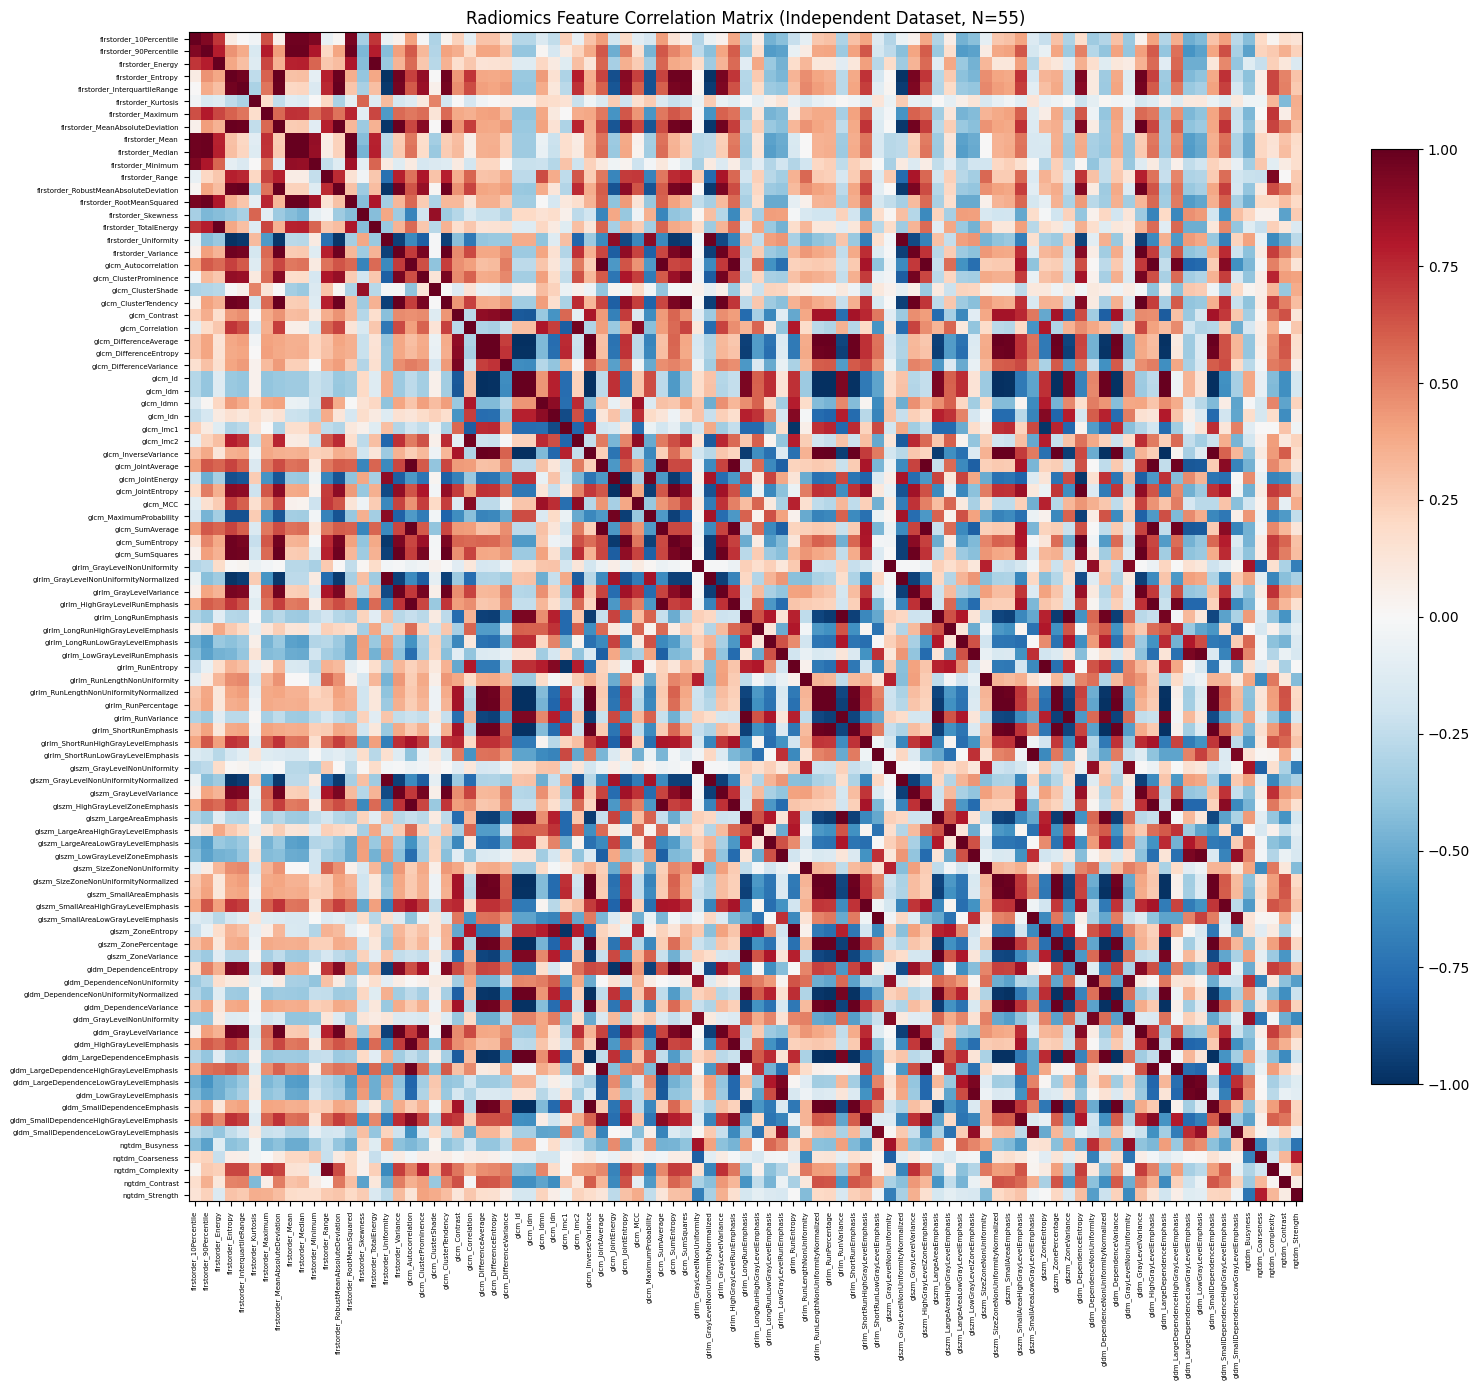

In [11]:
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
short_labels = [c.replace("original_", "") for c in feature_cols]
ax.set_xticklabels(short_labels, rotation=90, fontsize=5)
ax.set_yticklabels(short_labels, fontsize=5)
ax.set_title("Radiomics Feature Correlation Matrix (Independent Dataset, N=55)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join("reports", "19_correlation_heatmap_independent_normalised.png"), dpi=150)
plt.show()

## Save results

In [12]:
output_path = os.path.join("reports", "19_stats_independent_dataset_normalised.csv")
results_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print()
print("SUMMARY")
print(f"Dataset: {len(df)} independent studies (1 per patient)")
print(f"Total radiomics features tested: {len(results_df)}")
print(f"Uncorrected p < 0.05: {len(results_df[results_df['p_value'] < 0.05])}")
print(f"FDR-corrected p < 0.05: {results_df['significant_fdr'].sum()}")

Saved to reports/19_stats_independent_dataset_normalised.csv

SUMMARY
Dataset: 55 independent studies (1 per patient)
Total radiomics features tested: 93
Uncorrected p < 0.05: 24
FDR-corrected p < 0.05: 0


## Interpretation

**4 features reached uncorrected p < 0.05, but none survived FDR correction.** The top two are ngtdm_Busyness (p=0.024, Cohen's d=0.71) and ngtdm_Strength (p=0.025, rank-biserial r=-0.36). Two texture features (SmallAreaHighGrayLevelEmphasis, ShortRunHighGrayLevelEmphasis) tied at p=0.033 with identical values, indicating they capture the same information.

**The independent dataset found more uncorrected signal than the full dataset.** The full dataset (137 studies) had 0 features at p < 0.05; the independent dataset (55 studies) has 4. This is counterintuitive - fewer samples usually means less power. The likely explanation is that the selection rule (preferring rejection studies for dual-outcome patients) improved class balance (38% vs 28% rejection), and removing within-patient correlation reduced noise. However, none survive multiple testing correction, so this is not reliable signal.

**Different features rank at the top compared to the full dataset.** The full dataset's best feature was firstorder_Minimum (p=0.053); in the independent dataset it drops to p=0.069. The top independent features (ngtdm_Busyness, ngtdm_Strength) were unremarkable in the full dataset (p=0.164, p=0.361). This instability across datasets confirms these are not robust biomarkers.

**Correlation structure is similar.** 323 feature pairs with |r| > 0.9 (vs 300 in the full dataset). The slight increase is expected with fewer samples.

**Conclusion.** Removing repeated-measures bias does not reveal hidden signal. The 4 uncorrected hits do not survive FDR correction and involve different features than the full dataset. This reinforces the conclusion that B-mode radiomics features do not discriminate pancreas transplant rejection.